In [3]:
import os
import pdfplumber
import polars as pl
from pydantic import BaseModel, field_validator
from src.utils.converter import format_luas, format_number, format_pulau
from IPython.display import display

In [4]:
current_path = os.getcwd()
script_dir = os.path.dirname(current_path)
input_dir = os.path.join(script_dir, "datas")
print(current_path)
print(input_dir)

D:\Develop\repo\db-wilayah-indonesia\sources\notebooks
D:\Develop\repo\db-wilayah-indonesia\sources\datas


In [5]:
file_name = "Keputusan_Menteri_Dalam_Negeri_Nomor_300.2.2-2138_Tahun_2025.pdf"
pdf_path = os.path.join(input_dir, file_name)

In [15]:
kabupaten_kota_index_settings = {
    "vertical_strategy": "lines",
    "horizontal_strategy": "lines",
    "snap_y_tolerance": 7,
    "intersection_y_tolerance": 500,
    "intersection_x_tolerance": 500,
}

In [16]:
start_page_index = 619
end_page_index = 626

page_numbers = [start_page_index, end_page_index]


Processing page 1:


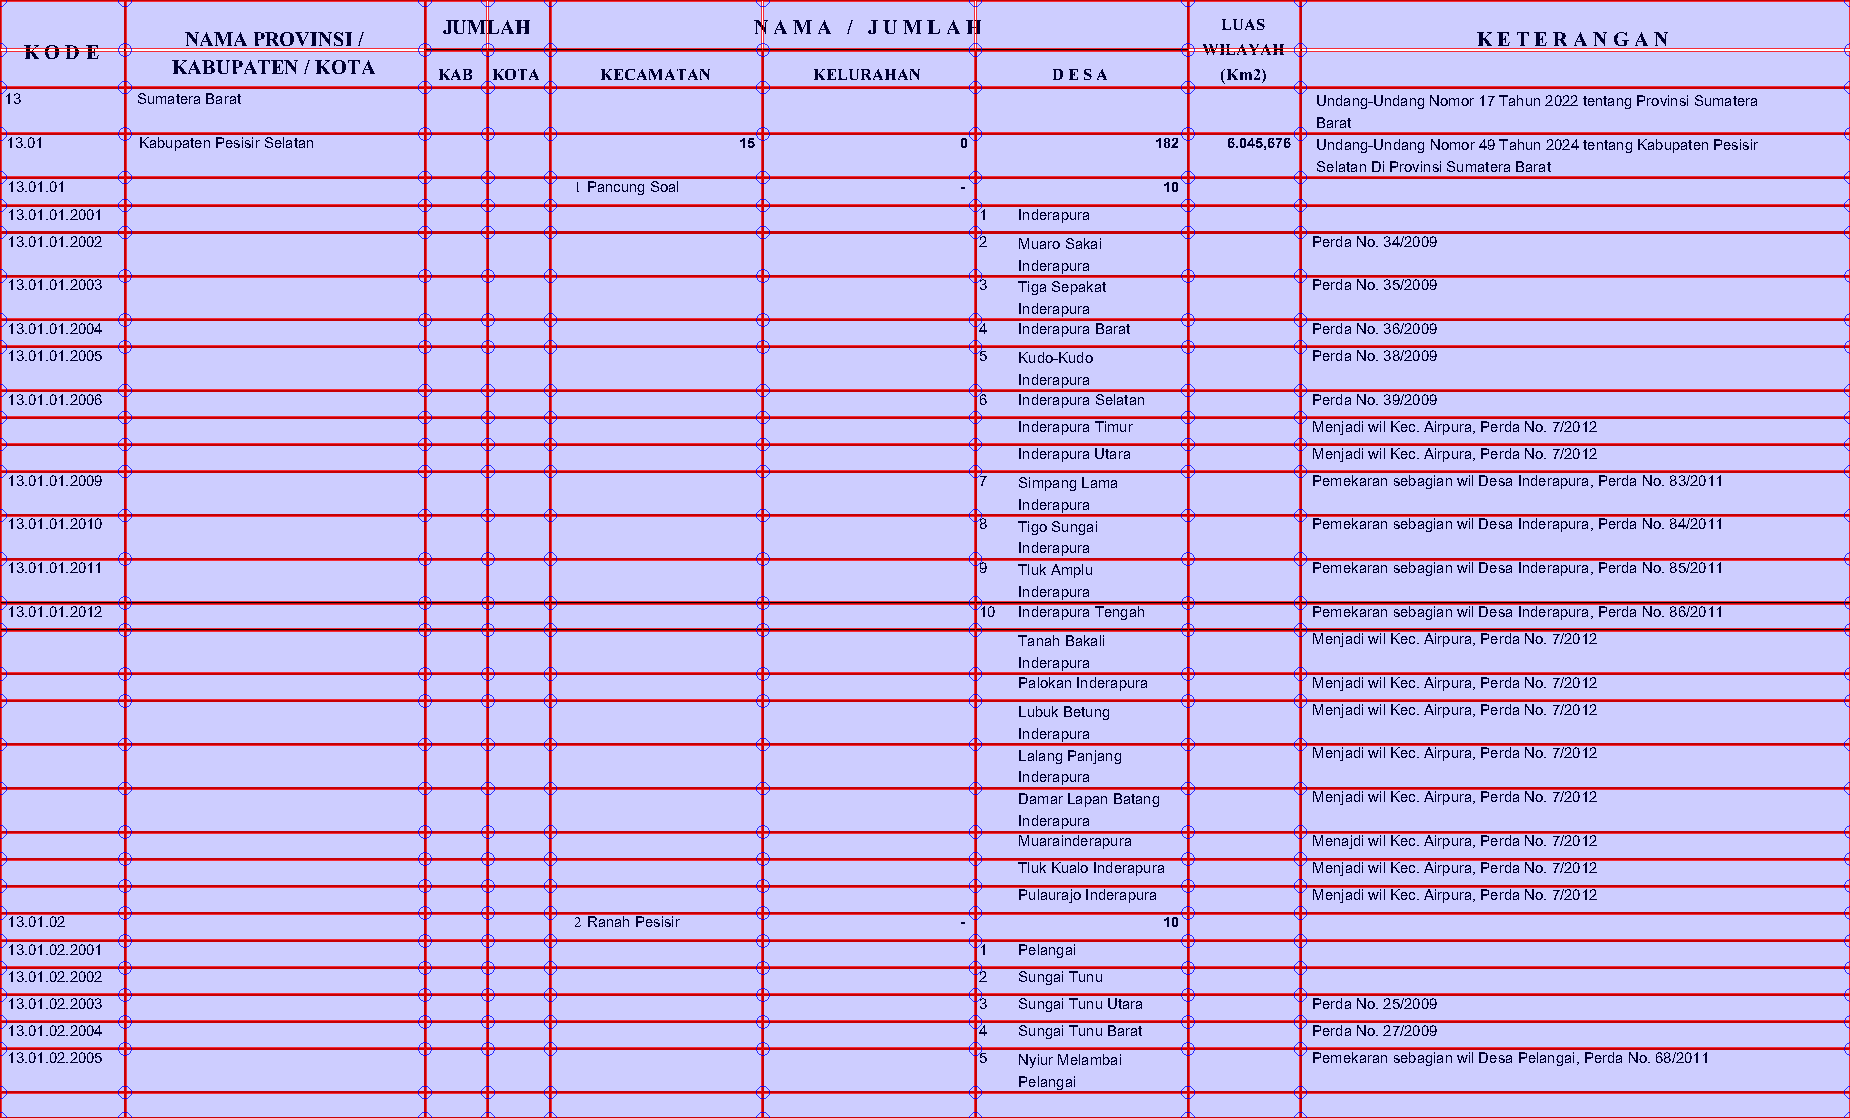


Processing page 2:


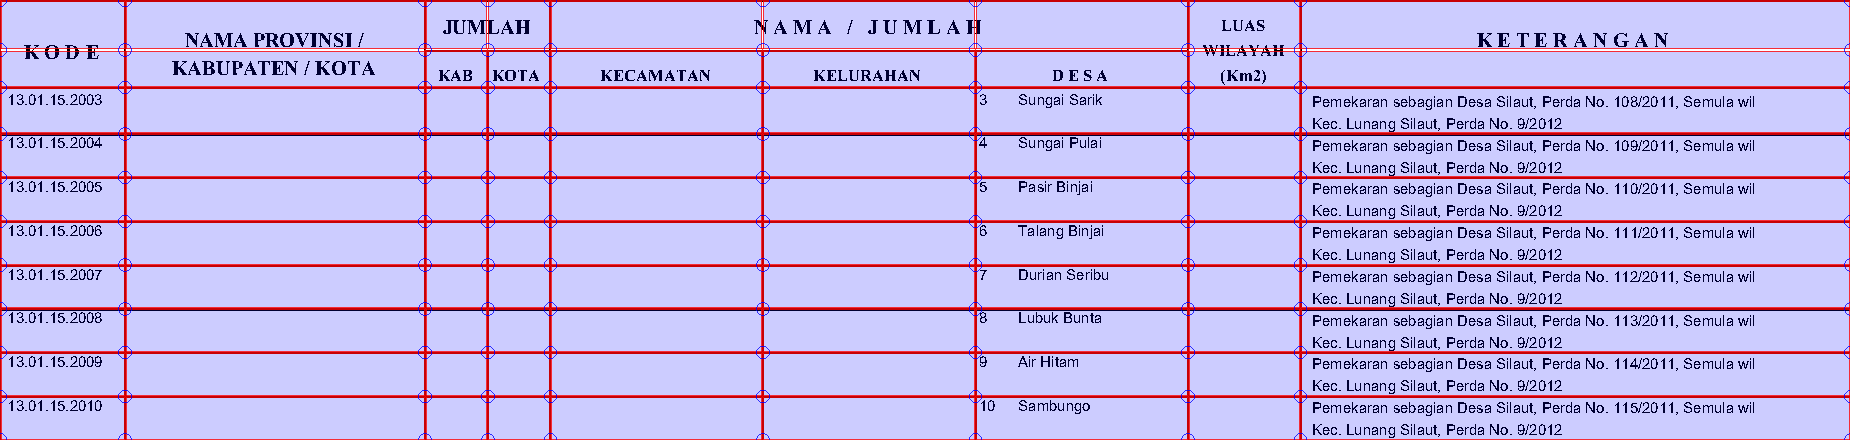

In [17]:
with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:
        for i, page in enumerate(pdf.pages):
            print(f"\nProcessing page {i + 1}:")
            table = page.find_table()
            if table is not None and table.bbox is not None:
                table_bbox = table.bbox
                the_table = page.crop(table_bbox)
                im = the_table.to_image(resolution=150)
                table_extract = im.debug_tablefinder(kabupaten_kota_index_settings)
                value_table = the_table.extract_table(kabupaten_kota_index_settings)
                display(table_extract)
                replacement_value = ""

In [18]:
raw_records = []

with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:

        for i, page in enumerate(pdf.pages):
            table = page.extract_table(kabupaten_kota_index_settings)
            if table is not None:
                for row in table:
                    if any(row) :
                        raw_records.append(row)
                        print(len(row))

9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9


In [19]:
def are_sublist_lengths_same(main_list):
    if not main_list:
        return True

    lengths = {len(sublist) for sublist in main_list}
    if len(lengths) == 1:
        return "Ok"
    else:
        raise ValueError("Not same length")


In [20]:
print(are_sublist_lengths_same(raw_records))
print(len(raw_records[0]))

Ok
9


In [21]:
raw_records

[['',
  'NAMA PROVINSI /',
  'JUM',
  'LAH',
  'N',
  'A M A / J U M L A H',
  '',
  'LUAS',
  'K E T E R A N G A N'],
 ['K O D E',
  'KABUPATEN / KOTA',
  'KAB',
  'KOTA',
  'KECAMATAN',
  'KELURAHAN',
  'D E S A',
  'WILAYAH\n(Km2)',
  ''],
 ['13',
  'Sumatera Barat',
  '',
  '',
  '',
  '',
  '',
  '',
  'Undang-Undang Nomor 17 Tahun 2022 tentang Provinsi Sumatera\nBarat'],
 ['13.01',
  'Kabupaten Pesisir Selatan',
  '',
  '',
  '15',
  '0',
  '182',
  '6.045,676',
  'Undang-Undang Nomor 49 Tahun 2024 tentang Kabupaten Pesisir\nSelatan Di Provinsi Sumatera Barat'],
 ['13.01.01', '', '', '', '1Pancung Soal', '-', '10', '', ''],
 ['13.01.01.2001', '', '', '', '', '', '1 Inderapura', '', ''],
 ['13.01.01.2002',
  '',
  '',
  '',
  '',
  '',
  '2 Muaro Sakai\nInderapura',
  '',
  'Perda No. 34/2009'],
 ['13.01.01.2003',
  '',
  '',
  '',
  '',
  '',
  '3 Tiga Sepakat\nInderapura',
  '',
  'Perda No. 35/2009'],
 ['13.01.01.2004',
  '',
  '',
  '',
  '',
  '',
  '4 Inderapura Barat',
  ''

In [13]:
class DistrictCityIndexData(BaseModel):
    no: int
    kode: str
    kabupaten_kota: str
    jumlah_kecamatan: int
    jumlah_kelurahan: int
    jumlah_desa: int
    luas_wilayah_km2: float
    jumlah_penduduk: int
    keterangan: str

    @field_validator(
        "no",
        "jumlah_kecamatan",
        "jumlah_kelurahan",
        "jumlah_desa",
        "jumlah_penduduk",
        mode="before",
    )
    @classmethod
    def validate_int_fields(cls, v):
        if v is None or v == "":
            return 0
        return int(format_number(v))

    @field_validator("luas_wilayah_km2", mode="before")
    @classmethod
    def validate_float_fields(cls, v):
        if v is None or v == "":
            return 0.0
        return float(format_luas(v))

    @field_validator("kode", "kabupaten_kota", "keterangan", mode="before")
    @classmethod
    def validate_str_fields(cls, v):
        return str(v) if v else ""

In [14]:
clean_records = []

i = 0
while i < len(raw_records):
    row = raw_records[i]
    if len(row) >= 9 and None not in row:
        first_cell = str(row[0]).strip() if row[0] else ""
        if first_cell and first_cell.isdigit():
            # Start of data row
            keterangan = str(row[8]) if row[8] else ""
            i += 1
            # Merge continuation rows
            while i < len(raw_records):
                next_row = raw_records[i]
                if (
                    len(next_row) >= 9
                    and None not in next_row
                    and str(next_row[0]).strip() == ""
                    and all(str(cell).strip() == "" for cell in next_row[:8])
                ):
                    keterangan += " " + str(next_row[8]) if next_row[8] else ""
                    i += 1
                else:
                    break

            try:
                # Create data with full keterangan
                data = DistrictCityIndexData(
                    no=row[0],
                    kode=row[1],
                    kabupaten_kota=row[2],
                    jumlah_kecamatan=row[3],
                    jumlah_kelurahan=row[4],
                    jumlah_desa=row[5],
                    luas_wilayah_km2=row[6],
                    jumlah_penduduk=row[7],
                    keterangan=keterangan,
                )
                clean_records.append(data)
            except (ValueError, IndexError) as e:
                raise ValueError(f"Failed to parse table row {row}: {e}")

        else:
            i += 1
    else:
        i += 1


ValueError: Failed to parse table row ['13', 'Sumatera Barat', 'KAB', 'KOTA', 'KECAMATAN', 'KELURAHAN', 'D E S A', '(Km2)', 'Undang-Undang Nomor 17 Tahun 2022 tentang Provinsi Sumatera\nBarat']: 5 validation errors for DistrictCityIndexData
jumlah_kecamatan
  Value error, invalid literal for int() with base 10: 'KOTA' [type=value_error, input_value='KOTA', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error
jumlah_kelurahan
  Value error, invalid literal for int() with base 10: 'KECAMATAN' [type=value_error, input_value='KECAMATAN', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error
jumlah_desa
  Value error, invalid literal for int() with base 10: 'KELURAHAN' [type=value_error, input_value='KELURAHAN', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error
luas_wilayah_km2
  Value error, could not convert string to float: 'D E S A' [type=value_error, inp

In [58]:
pl.DataFrame([data.model_dump() for data in clean_records])

no,kode,kabupaten_kota,jumlah_kecamatan,jumlah_kelurahan,jumlah_desa,luas_wilayah_km2,jumlah_penduduk,keterangan
i64,str,str,i64,i64,i64,f64,i64,str
1,"""13.01""","""Kabupaten Pesisir Selatan""",15,0,182,6045.676,533786,"""Undang-Undang Nomor 49 Tahun 2…"
2,"""13.02""","""Kabupaten Solok""",14,0,74,3590.404,413075,"""Undang-Undang Nomor 51 Tahun 2…"
3,"""13.03""","""Kabupaten Sijunjung""",8,0,62,3150.58,247323,"""Undang-Undang Nomor 50 Tahun 2…"
4,"""13.04""","""Kabupaten Tanah Datar""",14,0,75,1377.186,382674,"""Undang-Undang Nomor 52 Tahun 2…"
5,"""13.05""","""Kabupaten Padang Pariaman""",17,0,103,1341.879,458310,"""Perbaikan Nama Ibu Kota Kabupa…"
…,…,…,…,…,…,…,…,…
15,"""13.73""","""Kota Sawahlunto""",4,10,27,231.945,68559,"""Undang-Undang Nomor 57 Tahun 2…"
16,"""13.74""","""Kota Padang Panjang""",2,16,0,23.56,63895,"""Undang-Undang Nomor 54 Tahun 2…"
17,"""13.75""","""Kota Bukittinggi""",3,24,0,24.173,141804,"""Undang-Undang Nomor 53 Tahun 2…"
